# Finite-width wire magnetic field simulation in the lab frame

This notebook simulates the magnetic field generated by a finite straight wire above the `xy` plane.

## Geometry
- Scan area: `200 µm × 200 µm`
- Grid step: `5 µm`
- Observation plane: `z = 0`
- Wire direction: parallel to the `y-axis`
- Wire thickness: `50 µm`
- Wire height: `10 µm`
- Wire length: `200 µm`

## Current waveform
The applied current is biphasic:
- `0 mA` before the pulse
- `+2 mA` during the positive phase
- `-2 mA` during the negative phase

## Observable
The displayed signal is the lab-frame out-of-plane magnetic field component `Bz`, expressed in `nT`.

## What is computed
The wire is modeled as many parallel current filaments spread across the wire width.
Each filament is split into many short segments.
The total magnetic field is obtained by summing the Biot–Savart contribution from all segments.

## What is plotted
- a) time traces from all pixels, with spatial average and current stimulus
- c) magnetic field maps at one positive-phase and one negative-phase time
- d) time traces at selected points A and B on opposite sides of the wire
- e) horizontal line profiles at the same two times as in panel c

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True

## Set the geometry and grid AND WIRE

This cell defines:
- the scan region
- the wire dimensions
- the wire height
- the current amplitude
- the spatial grid used for the field calculation

In [2]:
mu0 = 4 * np.pi * 1e-7

I_total = 2e-3

L_scan_um = 200
step_um = 5

x_um = np.arange(-L_scan_um/2, L_scan_um/2 + step_um, step_um)
y_um = np.arange(-L_scan_um/2, L_scan_um/2 + step_um, step_um)

x = x_um * 1e-6
y = y_um * 1e-6

X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

wire_height_um = 10
wire_height = wire_height_um * 1e-6

wire_length_um = 200
wire_length = wire_length_um * 1e-6

wire_width_um = 50
wire_width = wire_width_um * 1e-6

y1 = -wire_length / 2
y2 =  wire_length / 2

Nfil = 41
x_filaments = np.linspace(-wire_width/2, wire_width/2, Nfil)

I_fil = I_total / Nfil

Nseg = 1000
t_wire = np.linspace(0, 1, Nseg + 1)

print("Number of filaments:", Nfil)
print("Filament x positions [um]:", x_filaments[0] * 1e6, "to", x_filaments[-1] * 1e6)
print("Current per filament [mA]:", I_fil * 1e3)
print("Number of segments per filament:", Nseg)

print("Grid shape:", X.shape)
print("Number of x points:", len(x_um))
print("Number of y points:", len(y_um))
print("x range [um]:", x_um[0], "to", x_um[-1])
print("y range [um]:", y_um[0], "to", y_um[-1])
print("Wire width [um]:", wire_width_um)
print("Wire height [um]:", wire_height_um)
print("Wire length [um]:", wire_length_um)
print("Current amplitude [mA]:", I_total * 1e3)

Number of filaments: 41
Filament x positions [um]: -24.999999999999996 to 24.999999999999996
Current per filament [mA]: 0.04878048780487805
Number of segments per filament: 1000
Grid shape: (41, 41)
Number of x points: 41
Number of y points: 41
x range [um]: -100.0 to 100.0
y range [um]: -100.0 to 100.0
Wire width [um]: 50
Wire height [um]: 10
Wire length [um]: 200
Current amplitude [mA]: 2.0


In [13]:
#define static current

t_ms = np.linspace(0, 90, 181)

current_mA = np.zeros_like(t_ms)

baseline_mA = 0.0
positive_mA = 2.0
negative_mA = -2.0

current_mA[:] = baseline_mA
current_mA[(t_ms >= 20) & (t_ms < 45)] = positive_mA
current_mA[(t_ms >= 45) & (t_ms < 70)] = negative_mA
current_mA[(t_ms >= 70)] = baseline_mA

current_A = current_mA * 1e-3

Bcube_nT = np.zeros((len(t_ms), len(y_um), len(x_um)))

for k in range(len(t_ms)):
    Bcube_nT[k] = (current_A[k] / I_total) * signal_map_nT

print("Time points:", len(t_ms))
print("Current unique values [mA]:", np.unique(current_mA))
print("Positive phase duration [ms]:", t_ms[(t_ms >= 20) & (t_ms < 45)][-1] - t_ms[(t_ms >= 20) & (t_ms < 45)][0] + (t_ms[1]-t_ms[0]))
print("Negative phase duration [ms]:", t_ms[(t_ms >= 45) & (t_ms < 70)][-1] - t_ms[(t_ms >= 45) & (t_ms < 70)][0] + (t_ms[1]-t_ms[0]))
print("Bcube shape:", Bcube_nT.shape)
print("Global min [nT]:", np.min(Bcube_nT))
print("Global max [nT]:", np.max(Bcube_nT))

Time points: 181
Current unique values [mA]: [-2.  0.  2.]
Positive phase duration [ms]: 25.0
Negative phase duration [ms]: 25.0
Bcube shape: (181, 41, 41)
Global min [nT]: -12343.045647436333
Global max [nT]: 12343.045647436333


In [14]:
t_pos_ms = 30.0
t_neg_ms = 55.0

it_pos = np.argmin(np.abs(t_ms - t_pos_ms))
it_neg = np.argmin(np.abs(t_ms - t_neg_ms))

print("Selected positive-phase time [ms]:", t_ms[it_pos], " current [mA]:", current_mA[it_pos])
print("Selected negative-phase time [ms]:", t_ms[it_neg], " current [mA]:", current_mA[it_neg])

iy0 = np.argmin(np.abs(y_um - 0))

xA_um, yA_um = -40, 0
xB_um, yB_um =  40, 0

ixA = np.argmin(np.abs(x_um - xA_um))
iyA = np.argmin(np.abs(y_um - yA_um))

ixB = np.argmin(np.abs(x_um - xB_um))
iyB = np.argmin(np.abs(y_um - yB_um))

print("Center horizontal cut at y [um]:", y_um[iy0])
print("Point A [um]:", (x_um[ixA], y_um[iyA]))
print("Point B [um]:", (x_um[ixB], y_um[iyB]))
print("Signal at A [nT]:", signal_map_nT[iyA, ixA])
print("Signal at B [nT]:", signal_map_nT[iyB, ixB])

Selected positive-phase time [ms]: 30.0  current [mA]: 2.0
Selected negative-phase time [ms]: 55.0  current [mA]: -2.0
Center horizontal cut at y [um]: 0.0
Point A [um]: (np.float64(-40.0), np.float64(0.0))
Point B [um]: (np.float64(40.0), np.float64(0.0))
Signal at A [nT]: 9714.556589726188
Signal at B [nT]: -9714.55658972617


## Plot a

This panel shows:
- all pixel traces in gray
- the full spatial average in orange
- the applied current stimulus in dashed black

In this ideal symmetric simulation, the spatial average is expected to cancel almost exactly.

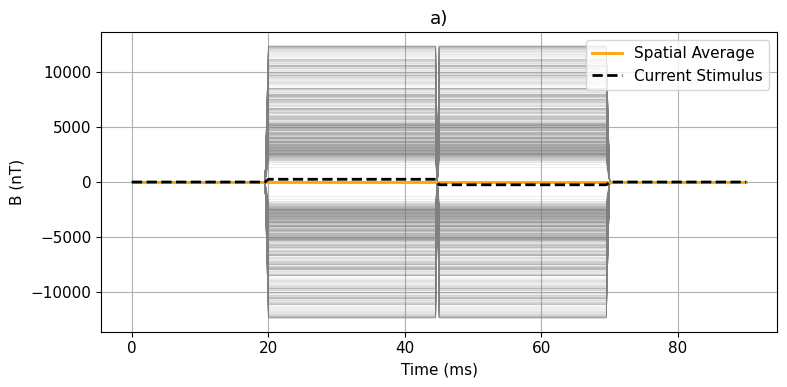

Number of traces: 1681
Spatial average min [nT]: -7.306256069447723e-12
Spatial average max [nT]: 7.306256069447723e-12


In [15]:
all_traces = Bcube_nT.reshape(len(t_ms), -1)
spatial_average = np.mean(all_traces, axis=1)

current_plot = 250 * current_mA / np.max(np.abs(current_mA)) if np.max(np.abs(current_mA)) > 0 else np.zeros_like(current_mA)

plt.figure(figsize=(8, 4))

for i in range(all_traces.shape[1]):
    plt.plot(t_ms, all_traces[:, i], color='gray', alpha=0.10, lw=0.5)

plt.plot(t_ms, spatial_average, color='orange', lw=2, label='Spatial Average')
plt.plot(t_ms, current_plot, 'k--', lw=2, label='Current Stimulus')

plt.xlabel('Time (ms)')
plt.ylabel('B (nT)')
plt.title('a)')
plt.legend()
plt.tight_layout()
plt.show()

print("Number of traces:", all_traces.shape[1])
print("Spatial average min [nT]:", np.min(spatial_average))
print("Spatial average max [nT]:", np.max(spatial_average))

## Plot c

This panel shows two magnetic field maps:
- one during the positive current phase
- one during the negative current phase

Points A and B are marked on the horizontal analysis cut.

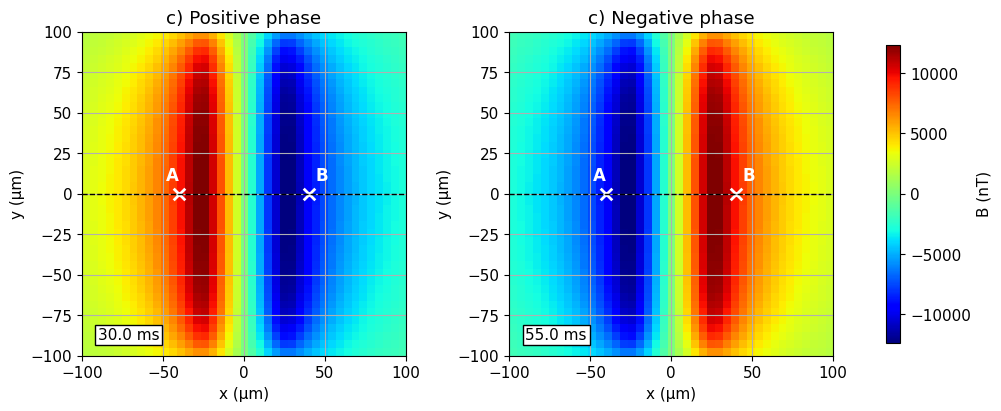

Positive-phase map min [nT]: -12343.045647436222
Positive-phase map max [nT]: 12343.045647436333
Negative-phase map min [nT]: -12343.045647436333
Negative-phase map max [nT]: 12343.045647436222


In [16]:
map_pos = Bcube_nT[it_pos]
map_neg = Bcube_nT[it_neg]

absmax_c = max(np.max(np.abs(map_pos)), np.max(np.abs(map_neg)))
if absmax_c == 0:
    absmax_c = 1.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

im1 = axes[0].imshow(
    map_pos,
    extent=[x_um.min(), x_um.max(), y_um.min(), y_um.max()],
    origin='lower',
    aspect='equal',
    cmap='jet',
    vmin=-absmax_c,
    vmax=absmax_c
)
axes[0].scatter([x_um[ixA], x_um[ixB]], [y_um[iyA], y_um[iyB]], c='white', marker='x', s=70, linewidths=2)
axes[0].plot([x_um.min(), x_um.max()], [0, 0], 'k--', lw=1)
axes[0].text(x_um[ixA] - 8, y_um[iyA] + 8, 'A', color='white', fontsize=12, weight='bold')
axes[0].text(x_um[ixB] + 4, y_um[iyB] + 8, 'B', color='white', fontsize=12, weight='bold')
axes[0].text(0.05, 0.05, f'{t_ms[it_pos]:.1f} ms', transform=axes[0].transAxes,
             bbox=dict(facecolor='white', edgecolor='black', pad=2))
axes[0].set_title('c) Positive phase')
axes[0].set_xlabel('x (µm)')
axes[0].set_ylabel('y (µm)')

im2 = axes[1].imshow(
    map_neg,
    extent=[x_um.min(), x_um.max(), y_um.min(), y_um.max()],
    origin='lower',
    aspect='equal',
    cmap='jet',
    vmin=-absmax_c,
    vmax=absmax_c
)
axes[1].scatter([x_um[ixA], x_um[ixB]], [y_um[iyA], y_um[iyB]], c='white', marker='x', s=70, linewidths=2)
axes[1].plot([x_um.min(), x_um.max()], [0, 0], 'k--', lw=1)
axes[1].text(x_um[ixA] - 8, y_um[iyA] + 8, 'A', color='white', fontsize=12, weight='bold')
axes[1].text(x_um[ixB] + 4, y_um[iyB] + 8, 'B', color='white', fontsize=12, weight='bold')
axes[1].text(0.05, 0.05, f'{t_ms[it_neg]:.1f} ms', transform=axes[1].transAxes,
             bbox=dict(facecolor='white', edgecolor='black', pad=2))
axes[1].set_title('c) Negative phase')
axes[1].set_xlabel('x (µm)')
axes[1].set_ylabel('y (µm)')

cbar = fig.colorbar(im2, ax=axes.ravel().tolist(), shrink=0.92)
cbar.set_label('B (nT)')

plt.show()

print("Positive-phase map min [nT]:", np.min(map_pos))
print("Positive-phase map max [nT]:", np.max(map_pos))
print("Negative-phase map min [nT]:", np.min(map_neg))
print("Negative-phase map max [nT]:", np.max(map_neg))

## Plot d

This panel shows the time traces at points A and B, together with the applied current stimulus.

Because A and B lie on opposite sides of the wire, their magnetic signals should have opposite polarity.

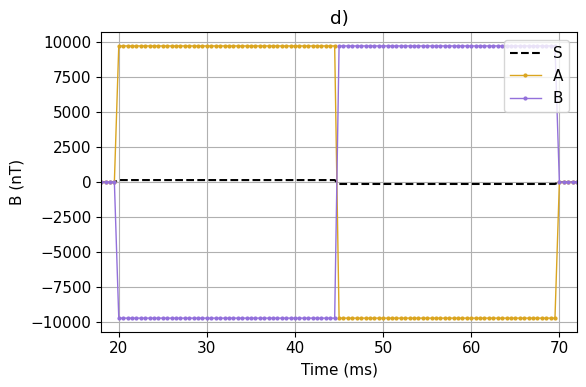

Trace A min [nT]: -9714.556589726188
Trace A max [nT]: 9714.556589726188
Trace B min [nT]: -9714.55658972617
Trace B max [nT]: 9714.55658972617


In [17]:
trace_A = Bcube_nT[:, iyA, ixA]
trace_B = Bcube_nT[:, iyB, ixB]

current_plot_small = 140 * current_mA / np.max(np.abs(current_mA)) if np.max(np.abs(current_mA)) > 0 else np.zeros_like(current_mA)

plt.figure(figsize=(6, 4))

plt.plot(t_ms, current_plot_small, 'k--', lw=1.5, label='S')
plt.plot(t_ms, trace_A, color='goldenrod', marker='o', markersize=2, lw=1, label='A')
plt.plot(t_ms, trace_B, color='mediumpurple', marker='o', markersize=2, lw=1, label='B')

plt.xlabel('Time (ms)')
plt.ylabel('B (nT)')
plt.title('d)')
plt.legend()
plt.xlim(18, 72)
plt.tight_layout()
plt.show()

print("Trace A min [nT]:", np.min(trace_A))
print("Trace A max [nT]:", np.max(trace_A))
print("Trace B min [nT]:", np.min(trace_B))
print("Trace B max [nT]:", np.max(trace_B))

## Plot e

This panel shows horizontal line profiles across the sensing plane at the same two times used in panel c.

The positive-phase and negative-phase profiles should have opposite sign.

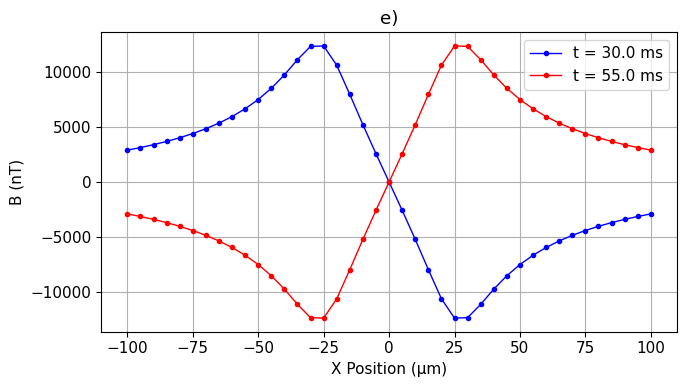

Positive-phase profile min [nT]: -12343.045647436222
Positive-phase profile max [nT]: 12343.045647436333
Negative-phase profile min [nT]: -12343.045647436333
Negative-phase profile max [nT]: 12343.045647436222
Horizontal profile taken at y [um]: 0.0


In [18]:
profile_pos = Bcube_nT[it_pos, iy0, :]
profile_neg = Bcube_nT[it_neg, iy0, :]

plt.figure(figsize=(7, 4))

plt.plot(x_um, profile_pos, color='blue', marker='o', markersize=3, lw=1, label=f't = {t_ms[it_pos]:.1f} ms')
plt.plot(x_um, profile_neg, color='red', marker='o', markersize=3, lw=1, label=f't = {t_ms[it_neg]:.1f} ms')

plt.xlabel('X Position (µm)')
plt.ylabel('B (nT)')
plt.title('e)')
plt.legend()
plt.tight_layout()
plt.show()

print("Positive-phase profile min [nT]:", np.min(profile_pos))
print("Positive-phase profile max [nT]:", np.max(profile_pos))
print("Negative-phase profile min [nT]:", np.min(profile_neg))
print("Negative-phase profile max [nT]:", np.max(profile_neg))
print("Horizontal profile taken at y [um]:", y_um[iy0])